# MAGIS-100 NDK Dephasing Forecast Generator

**Author:** Eric C. Thompson  
**Related Publication:** [Zenodo DOI](https://doi.org/10.5281/zenodo.19389059)

This notebook generates closure-normalized forecasts for momentum-quadratic residual dephasing in a MAGIS-100-like atom interferometer within the Null-Directional Kinematics (NDK) transport framework.

## Overview
In the NDK framework, spacetime is modeled as a directional transport substrate with finite informational capacity. In the reduced matter-wave sector, a large-momentum-transfer (LMT) atom interferometer places an additional transport burden on widely separated branches, producing a residual dephasing component beyond ordinary technical pulse-loss channels.

The forecast shown here is based on the closure-normalized thermal law used in the related MAGIS-100 note. In this formulation, the leading residual dephasing scales:
- quadratically with LMT order $n$,
- linearly with interrogation time $T$,
- linearly with source temperature $\Theta$,
- and quadratically with both the effective wavevector $k_{\rm eff}$ and transverse coherence-support width $w_{\rm coh}$.

The main purpose of the notebook is to visualize the shape of this predicted residual scaling law and to show how its magnitude changes across experimentally relevant preparation-side and transfer-side choices.

## How to Read the Plot
- **Solid red curve:** baseline median forecast for a favorable operating point with $T = 9\,\mathrm{s}$, $\Theta = 400\,\mathrm{pK}$, $k_{\rm eff}=1.0\times10^7\,\mathrm{m}^{-1}$, and $w_{\rm coh}=30\,\mu\mathrm{m}$.
- **Shaded red band:** model-side transfer sensitivity range obtained by sweeping $\Theta$, $k_{\rm eff}$, and $w_{\rm coh}$ over representative low-side and high-side values. This is not an experimental error bar.
- **Black threshold lines:** approximate 0.1% and 1.0% contrast-loss benchmarks for residual visibility loss.
- **Vertical reference lines:** illustrative markers for current-technology-scale LMT and the MAGIS-100 target regime.

## Experimental Usage
Experimental users can modify:
- `T_BASE` to explore different interrogation times,
- `THETA_BASE` and the temperature range to test alternate source-preparation conditions,
- `K_EFF_BASE` and its sweep range to examine transfer dependence on effective momentum scale,
- and `W_COH_BASE` and its sweep range to study sensitivity to transverse coherence-support width.

The practical value of the notebook is not just a single magnitude estimate, but a compact visualization of the predicted residual scaling structure across experimentally controllable variables.

## Theoretical Foundation & Reference Papers
The equations and geometric constants used in this simulation are derived from the Null-Directional Kinematics (NDK) framework. For the full mathematical derivations of the underlying theory, the transport model, and the primitive-cell normalization used here, please refer to the following foundational papers:

* **Core NDK Framework:** Thompson, E. C. (2026). *Null-Directional Kinematics and the Statistical Structure of Spacetime: Clock Functionals, Transport Geometry, and Directional Support* (Version v6). Zenodo. [https://doi.org/10.5281/zenodo.18665370](https://doi.org/10.5281/zenodo.18665370)

* **Primary LMT Dephasing Model:** Thompson, E. C. (2026). *Macroscopic Dephasing in LMT Atom Interferometry: A Short Letter on the NDK Momentum-Quadratic Contrast Floor* (Version v4). Zenodo. [https://doi.org/10.5281/zenodo.19186680](https://doi.org/10.5281/zenodo.19186680)

* **Closure / Primitive-Cell Normalization:** Thompson, E. C. (2026). *A Conditional Closure Mechanism for G and $\hbar$ in a Primitive NDK Horizon Cell Model*. Zenodo. [https://doi.org/10.5281/zenodo.19375997](https://doi.org/10.5281/zenodo.19375997)

Baseline thermal prefactor A = 4.083e-02 K^-1 s^-1
Low-side thermal prefactor A = 1.161e-02 K^-1 s^-1
High-side thermal prefactor A = 1.045e-01 K^-1 s^-1

Representative values at n=1000:
D_pred(n=1000, T=9.0s, Theta=400pK, k_eff=1.00e7, w_coh=30um) = 1.470e-04
D_pred(n=1000, T=9.0s, Theta=300pK, k_eff=0.80e7, w_coh=20um) = 3.136e-05
D_pred(n=1000, T=9.0s, Theta=600pK, k_eff=1.20e7, w_coh=40um) = 5.644e-04


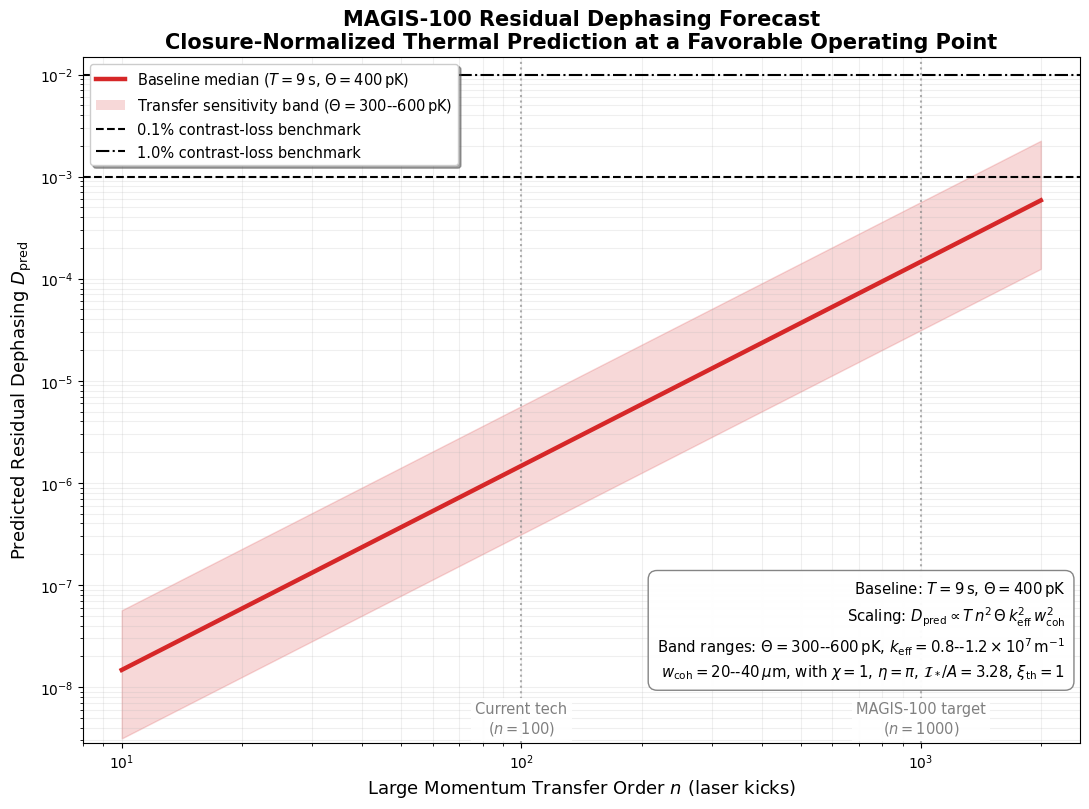

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------
# MAGIS-100 closure-normalized forecast
#
# Single-baseline figure focused on a favorable operating point:
#
#   T = 9 s
#   Theta = 400 pK
#
# Sensitivity band:
#   Theta   : 300–600 pK
#   w_coh   : 20–40 microns
#   k_eff   : 0.8e7 – 1.2e7 m^-1
#
# Full thermal law:
#
# D_pred(Theta) =
#   [chi / (2 eta xi_th^2)] * (I_*/A) * c * l_P
#   * T * n^2 * k_eff^2 * w_coh^2 * (m k_B Theta / hbar^2)
# ------------------------------------------------------------

# -----------------------------
# Fundamental constants (SI)
# -----------------------------
C = 299_792_458.0
L_PLANCK = 1.616_255e-35
HBAR = 1.054_571_817e-34
K_B = 1.380_649e-23
AMU = 1.660_539_066_60e-27

# -----------------------------
# Atomic species
# -----------------------------
# Sr-87 baseline
M_ATOM = 87.0 * AMU

# -----------------------------
# Closure / geometry inputs
# -----------------------------
CHI = 1.0
ETA = math.pi
I_STAR_OVER_A = 3.28
XI_TH = 1.0

# -----------------------------
# Experimental baseline inputs
# -----------------------------
T_BASE = 9.0
THETA_BASE = 400e-12      # 400 pK baseline
K_EFF_BASE = 1.0e7        # 1/m
W_COH_BASE = 30e-6        # 30 microns

# -----------------------------
# Sensitivity ranges
# -----------------------------
THETA_MIN = 300e-12
THETA_MAX = 600e-12

W_COH_MIN = 20e-6
W_COH_MAX = 40e-6

K_EFF_MIN = 0.8e7
K_EFF_MAX = 1.2e7


def thermal_prefactor(
    chi=CHI,
    eta=ETA,
    i_star_over_a=I_STAR_OVER_A,
    xi_th=XI_TH,
    k_eff=K_EFF_BASE,
    w_coh=W_COH_BASE,
    m_atom=M_ATOM,
):
    """
    Returns coefficient A such that:
        D_pred = A * T * n^2 * Theta
    with Theta in kelvin.
    """
    geom_part = (chi / (2.0 * eta * xi_th**2)) * i_star_over_a
    vacuum_part = C * L_PLANCK
    lab_part = (k_eff**2) * (w_coh**2) * (m_atom * K_B / HBAR**2)
    return geom_part * vacuum_part * lab_part


def predict_dephasing(
    n,
    T,
    Theta,
    chi=CHI,
    eta=ETA,
    i_star_over_a=I_STAR_OVER_A,
    xi_th=XI_TH,
    k_eff=K_EFF_BASE,
    w_coh=W_COH_BASE,
    m_atom=M_ATOM,
):
    """
    Full closure-normalized thermal forecast.
    """
    A = thermal_prefactor(
        chi=chi,
        eta=eta,
        i_star_over_a=i_star_over_a,
        xi_th=xi_th,
        k_eff=k_eff,
        w_coh=w_coh,
        m_atom=m_atom,
    )
    return A * T * (n**2) * Theta


# -----------------------------
# n-grid
# -----------------------------
n_vals = np.logspace(1, 3.3, 450)   # 10 to ~2000

# -----------------------------
# Baseline median curve
# -----------------------------
D_med = predict_dephasing(
    n_vals,
    T=T_BASE,
    Theta=THETA_BASE,
    k_eff=K_EFF_BASE,
    w_coh=W_COH_BASE
)

# -----------------------------
# Sensitivity band
# low = all low-side transfer choices
# high = all high-side transfer choices
# -----------------------------
D_low = predict_dephasing(
    n_vals,
    T=T_BASE,
    Theta=THETA_MIN,
    k_eff=K_EFF_MIN,
    w_coh=W_COH_MIN
)

D_high = predict_dephasing(
    n_vals,
    T=T_BASE,
    Theta=THETA_MAX,
    k_eff=K_EFF_MAX,
    w_coh=W_COH_MAX
)

# -----------------------------
# Print benchmark numbers
# -----------------------------
A_base = thermal_prefactor(k_eff=K_EFF_BASE, w_coh=W_COH_BASE)
A_low = thermal_prefactor(k_eff=K_EFF_MIN, w_coh=W_COH_MIN)
A_high = thermal_prefactor(k_eff=K_EFF_MAX, w_coh=W_COH_MAX)

print(f"Baseline thermal prefactor A = {A_base:.3e} K^-1 s^-1")
print(f"Low-side thermal prefactor A = {A_low:.3e} K^-1 s^-1")
print(f"High-side thermal prefactor A = {A_high:.3e} K^-1 s^-1")

def report_point(T, Theta, k_eff, w_coh, n=1000):
    val = predict_dephasing(np.array([n]), T=T, Theta=Theta, k_eff=k_eff, w_coh=w_coh)[0]
    print(
        f"D_pred(n={n}, T={T:.1f}s, Theta={Theta*1e12:.0f}pK, "
        f"k_eff={k_eff/1e7:.2f}e7, w_coh={w_coh*1e6:.0f}um) = {val:.3e}"
    )

print("\nRepresentative values at n=1000:")
report_point(T_BASE, THETA_BASE, K_EFF_BASE, W_COH_BASE)
report_point(T_BASE, THETA_MIN, K_EFF_MIN, W_COH_MIN)
report_point(T_BASE, THETA_MAX, K_EFF_MAX, W_COH_MAX)

# -----------------------------
# Plot styling
# -----------------------------
COLOR_BASE = "#d62728"      # red
THRESHOLD_COLOR = "black"
REFERENCE_COLOR = "gray"

plt.rcParams["font.family"] = "sans-serif"
fig, ax = plt.subplots(figsize=(11, 8.2))

# Sensitivity band
ax.fill_between(n_vals, D_low, D_high, color=COLOR_BASE, alpha=0.18, zorder=1)

# Baseline median curve
ax.plot(n_vals, D_med, color=COLOR_BASE, linewidth=3.2, linestyle="-", zorder=3)

# Reference lines
ax.axvline(100, linestyle=":", linewidth=1.5, color=REFERENCE_COLOR, alpha=0.65, zorder=1)
ax.axvline(1000, linestyle=":", linewidth=1.5, color=REFERENCE_COLOR, alpha=0.65, zorder=1)
ax.axhline(1e-3, linestyle="--", linewidth=1.5, color=THRESHOLD_COLOR, zorder=2)
ax.axhline(1e-2, linestyle="-.", linewidth=1.5, color=THRESHOLD_COLOR, zorder=2)

# Axes
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(8, 2500)

ymin = min(np.min(D_low), 5e-7) * 0.9
ymax = max(np.max(D_high), 1e-2) * 1.5
ax.set_ylim(ymin, ymax)

ax.set_xlabel(r"Large Momentum Transfer Order $n$ (laser kicks)", fontsize=13)
ax.set_ylabel(r"Predicted Residual Dephasing $D_{\mathrm{pred}}$", fontsize=13)
ax.set_title(
    "MAGIS-100 Residual Dephasing Forecast\n"
    r"Closure-Normalized Thermal Prediction at a Favorable Operating Point",
    fontsize=15,
    fontweight="bold"
)

ax.grid(True, which="both", alpha=0.20)

# -----------------------------
# Annotations
# -----------------------------
TEXT_BBOX = dict(facecolor="white", alpha=0.93, edgecolor="none", pad=3.0)

ax.text(
    100, ymin * 1.15,
    "Current tech\n($n=100$)",
    ha="center", va="bottom",
    fontsize=10.5, color=REFERENCE_COLOR, bbox=TEXT_BBOX
)

ax.text(
    1000, ymin * 1.15,
    "MAGIS-100 target\n($n=1000$)",
    ha="center", va="bottom",
    fontsize=10.5, color=REFERENCE_COLOR, bbox=TEXT_BBOX
)

explanation_text = (
    r"Baseline: $T=9\,\mathrm{s}$, $\Theta=400\,\mathrm{pK}$" "\n"
    r"Scaling: $D_{\mathrm{pred}}\propto T\,n^2\,\Theta\,k_{\rm eff}^2\,w_{\mathrm{coh}}^2$" "\n"
    r"Band ranges: $\Theta=300$--$600\,\mathrm{pK}$, $k_{\rm eff}=0.8$--$1.2\times10^7\,\mathrm{m}^{-1}$" "\n"
    r"$w_{\mathrm{coh}}=20$--$40\,\mu\mathrm{m}$, with $\chi=1$, $\eta=\pi$, $\mathcal{I}_*/A=3.28$, $\xi_{\mathrm{th}}=1$"
)

ax.text(
    0.985, 0.09,
    explanation_text,
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=10.7,
    linespacing=1.40,
    bbox=dict(facecolor="white", alpha=0.96, edgecolor="gray", boxstyle="round,pad=0.6")
)

# Legend
legend_handles = [
    Line2D([0], [0], color=COLOR_BASE, lw=3.2,
           label=r"Baseline median ($T=9\,\mathrm{s}$, $\Theta=400\,\mathrm{pK}$)"),
    Patch(facecolor=COLOR_BASE, alpha=0.18,
          label=r"Transfer sensitivity band ($\Theta=300$--$600\,\mathrm{pK}$)"),
    Line2D([0], [0], color=THRESHOLD_COLOR, lw=1.5, linestyle="--",
           label="0.1% contrast-loss benchmark"),
    Line2D([0], [0], color=THRESHOLD_COLOR, lw=1.5, linestyle="-.",
           label="1.0% contrast-loss benchmark"),
]

ax.legend(handles=legend_handles, loc="upper left", fontsize=10.5, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

## MAGIS-100 Experimental Transfer Reach

This figure isolates one of the most practical experimental levers in the closure-normalized NDK forecast: the transverse coherence-support width $w_{\mathrm{coh}}$. Rather than plotting the full $n$-dependence, it fixes a favorable MAGIS-100 operating point at $T=9\,\mathrm{s}$ and $n=1000$ and shows how the predicted residual dephasing changes as $w_{\mathrm{coh}}$ is varied across a representative preparation range. :contentReference[oaicite:0]{index=0}

Within the thermal version of the forecast, the residual law at fixed $T$, $n$, and $k_{\rm eff}$ scales as
\[
D_{\mathrm{pred}} \propto w_{\mathrm{coh}}^2\,\Theta,
\]
so broader transverse coherence-support width and warmer source preparation both increase the predicted residual burden. This makes the plot useful as a preparation-side reach map: it shows how strongly the predicted signal moves as laboratory source conditions are relaxed or tuned within a plausible ultracold operating regime. :contentReference[oaicite:1]{index=1}

### How to Read the Plot
- **Colored curves:** closure-normalized forecasts for fixed temperature families $\Theta = 200,\ 300,\ 400,\ 500,\ 600\,\mathrm{pK}$.
- **Horizontal black lines:** approximate 0.1% and 1.0% contrast-loss benchmarks.
- **Vertical dotted lines:** reference preparation widths at $30\,\mu\mathrm{m}$, $50\,\mu\mathrm{m}$, and $70\,\mu\mathrm{m}$, labeled as conservative, representative, and extended preparation regimes. :contentReference[oaicite:2]{index=2}

The purpose of this figure is not to claim that MAGIS-100 will necessarily operate at the broadest or warmest end of this range. Rather, it shows that the closure-normalized transport signal remains highly suppressed under tighter and colder preparation, but can move materially closer to practical visibility when $w_{\mathrm{coh}}$ and $\Theta$ are increased together. In that sense, the plot serves as an experimental strategy figure: it identifies where source-preparation choices provide the strongest leverage for testing the predicted transport-induced residual dephasing. :contentReference[oaicite:3]{index=3}

Representative values:
D_pred(T=9s, n=1000, Theta=200 pK, w_coh=30 um) = 7.349e-05
D_pred(T=9s, n=1000, Theta=300 pK, w_coh=30 um) = 1.102e-04
D_pred(T=9s, n=1000, Theta=400 pK, w_coh=30 um) = 1.470e-04
D_pred(T=9s, n=1000, Theta=500 pK, w_coh=30 um) = 1.837e-04
D_pred(T=9s, n=1000, Theta=600 pK, w_coh=30 um) = 2.205e-04

D_pred(T=9s, n=1000, Theta=200 pK, w_coh=45 um) = 1.654e-04
D_pred(T=9s, n=1000, Theta=300 pK, w_coh=45 um) = 2.480e-04
D_pred(T=9s, n=1000, Theta=400 pK, w_coh=45 um) = 3.307e-04
D_pred(T=9s, n=1000, Theta=500 pK, w_coh=45 um) = 4.134e-04
D_pred(T=9s, n=1000, Theta=600 pK, w_coh=45 um) = 4.961e-04

D_pred(T=9s, n=1000, Theta=200 pK, w_coh=60 um) = 2.940e-04
D_pred(T=9s, n=1000, Theta=300 pK, w_coh=60 um) = 4.410e-04
D_pred(T=9s, n=1000, Theta=400 pK, w_coh=60 um) = 5.879e-04
D_pred(T=9s, n=1000, Theta=500 pK, w_coh=60 um) = 7.349e-04
D_pred(T=9s, n=1000, Theta=600 pK, w_coh=60 um) = 8.819e-04


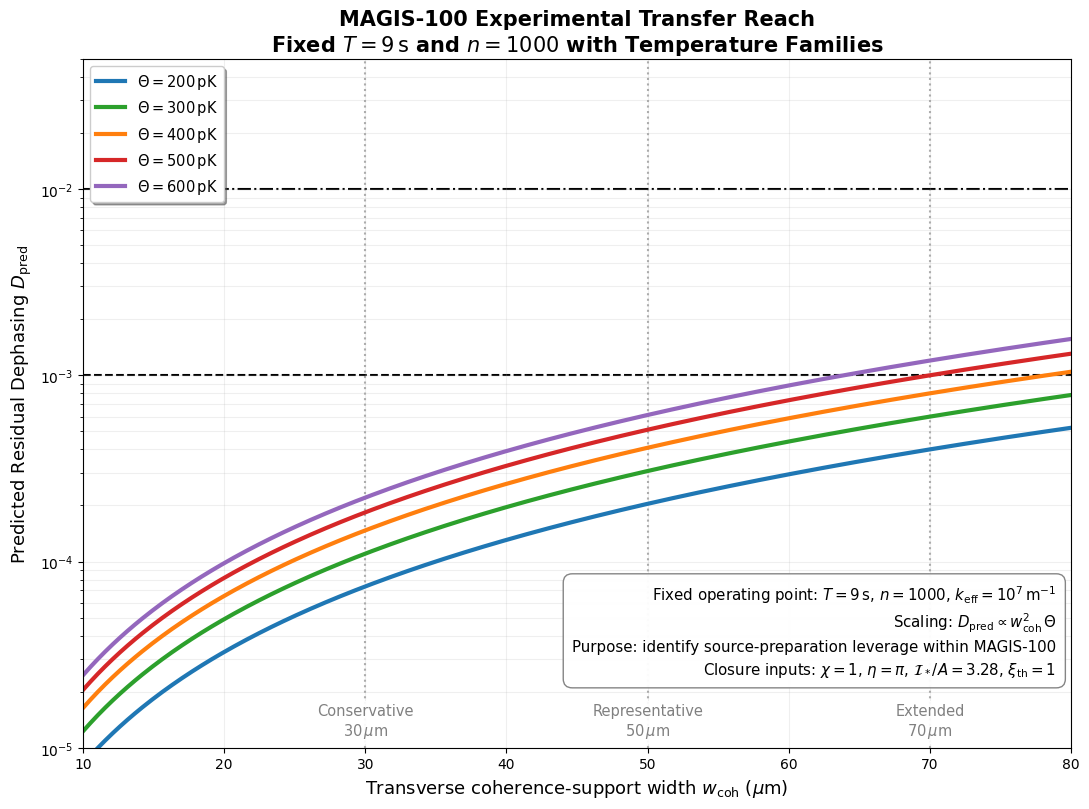

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# MAGIS-100 Experimental Transfer Reach
#
# Fixed operating point:
#   T = 9 s
#   n = 1000
#
# Variable lever:
#   w_coh (transverse coherence-support width)
#
# Temperature families:
#   Theta = 200, 300, 400, 500, 600 pK
#
# Full thermal law:
#
# D_pred(Theta) =
#   [chi / (2 eta xi_th^2)] * (I_*/A) * c * l_P
#   * T * n^2 * k_eff^2 * w_coh^2 * (m k_B Theta / hbar^2)
# ------------------------------------------------------------

# -----------------------------
# Fundamental constants (SI)
# -----------------------------
C = 299_792_458.0
L_PLANCK = 1.616_255e-35
HBAR = 1.054_571_817e-34
K_B = 1.380_649e-23
AMU = 1.660_539_066_60e-27

# -----------------------------
# Atomic species
# -----------------------------
M_ATOM = 87.0 * AMU   # Sr-87 baseline

# -----------------------------
# Closure / geometry inputs
# -----------------------------
CHI = 1.0
ETA = math.pi
I_STAR_OVER_A = 3.28
XI_TH = 1.0

# -----------------------------
# Fixed MAGIS operating point
# -----------------------------
T_FIXED = 9.0
N_FIXED = 1000
K_EFF_FIXED = 1.0e7   # 1/m

# -----------------------------
# Sweep range for w_coh
# -----------------------------
wcoh_um = np.linspace(10, 80, 400)       # microns for plotting
wcoh_m = wcoh_um * 1e-6                  # meters for calculation

# -----------------------------
# Temperature families
# -----------------------------
theta_families_pk = [200, 300, 400, 500, 600]  # pK
theta_families_K = [x * 1e-12 for x in theta_families_pk]

# -----------------------------
# Full thermal law
# -----------------------------
def thermal_prefactor(
    chi=CHI,
    eta=ETA,
    i_star_over_a=I_STAR_OVER_A,
    xi_th=XI_TH,
    k_eff=K_EFF_FIXED,
    m_atom=M_ATOM,
):
    """
    Returns coefficient A such that:
        D_pred = A * T * n^2 * w_coh^2 * Theta
    with w_coh in meters and Theta in kelvin.
    """
    geom_part = (chi / (2.0 * eta * xi_th**2)) * i_star_over_a
    vacuum_part = C * L_PLANCK
    atom_part = (k_eff**2) * (m_atom * K_B / HBAR**2)
    return geom_part * vacuum_part * atom_part


def predict_dephasing_vs_wcoh(
    w_coh,
    Theta,
    T=T_FIXED,
    n=N_FIXED,
    chi=CHI,
    eta=ETA,
    i_star_over_a=I_STAR_OVER_A,
    xi_th=XI_TH,
    k_eff=K_EFF_FIXED,
    m_atom=M_ATOM,
):
    """
    Full closure-normalized thermal forecast as a function of w_coh.
    """
    A = thermal_prefactor(
        chi=chi,
        eta=eta,
        i_star_over_a=i_star_over_a,
        xi_th=xi_th,
        k_eff=k_eff,
        m_atom=m_atom,
    )
    return A * T * (n**2) * (w_coh**2) * Theta


# -----------------------------
# Compute curves
# -----------------------------
curves = {}
for theta_pk, theta_K in zip(theta_families_pk, theta_families_K):
    curves[theta_pk] = predict_dephasing_vs_wcoh(wcoh_m, theta_K)

# -----------------------------
# Report reach points
# -----------------------------
def report(theta_pk, w_um):
    theta_K = theta_pk * 1e-12
    val = predict_dephasing_vs_wcoh(np.array([w_um * 1e-6]), theta_K)[0]
    print(f"D_pred(T=9s, n=1000, Theta={theta_pk} pK, w_coh={w_um} um) = {val:.3e}")

print("Representative values:")
for theta_pk in [200, 300, 400, 500, 600]:
    report(theta_pk, 30)
print()
for theta_pk in [200, 300, 400, 500, 600]:
    report(theta_pk, 45)
print()
for theta_pk in [200, 300, 400, 500, 600]:
    report(theta_pk, 60)

# -----------------------------
# Plot styling
# -----------------------------
COLORS = {
    200: "#1f77b4",  # blue
    300: "#2ca02c",  # green
    400: "#ff7f0e",  # orange
    500: "#d62728",  # red
    600: "#9467bd",  # purple
}

TEXT_BBOX = dict(facecolor="white", alpha=0.93, edgecolor="none", pad=3.0)

plt.rcParams["font.family"] = "sans-serif"
fig, ax = plt.subplots(figsize=(11, 8.2))

# Plot temperature families
for theta_pk in theta_families_pk:
    ax.plot(
        wcoh_um,
        curves[theta_pk],
        linewidth=3.0,
        color=COLORS[theta_pk],
        label=rf"$\Theta={theta_pk}\,\mathrm{{pK}}$"
    )

# Reference vertical lines
ax.axvline(30, linestyle=":", linewidth=1.5, color="gray", alpha=0.65, zorder=1)
ax.axvline(50, linestyle=":", linewidth=1.5, color="gray", alpha=0.65, zorder=1)
ax.axvline(70, linestyle=":", linewidth=1.5, color="gray", alpha=0.65, zorder=1)

# Contrast-loss benchmarks
ax.axhline(1e-3, linestyle="--", linewidth=1.5, color="black", zorder=1)
ax.axhline(1e-2, linestyle="-.", linewidth=1.5, color="black", zorder=1)

# Axes
ax.set_yscale("log")
ax.set_xlim(10, 80)
ax.set_ylim(1e-5, 5e-2)

ax.set_xlabel(r"Transverse coherence-support width $w_{\mathrm{coh}}$ ($\mu$m)", fontsize=13)
ax.set_ylabel(r"Predicted Residual Dephasing $D_{\mathrm{pred}}$", fontsize=13)
ax.set_title(
    "MAGIS-100 Experimental Transfer Reach\n"
    r"Fixed $T=9\,\mathrm{s}$ and $n=1000$ with Temperature Families",
    fontsize=15,
    fontweight="bold"
)

ax.grid(True, which="both", alpha=0.20)

# Annotations
ax.text(
    30, 1.1e-5,
    "Conservative\n" r"$30\,\mu$m",
    ha="center", va="bottom",
    fontsize=10.5, color="gray", bbox=TEXT_BBOX
)

ax.text(
    50, 1.1e-5,
    "Representative\n" r"$50\,\mu$m",
    ha="center", va="bottom",
    fontsize=10.5, color="gray", bbox=TEXT_BBOX
)

ax.text(
    70, 1.1e-5,
    "Extended\n" r"$70\,\mu$m",
    ha="center", va="bottom",
    fontsize=10.5, color="gray", bbox=TEXT_BBOX
)

explanation_text = (
    r"Fixed operating point: $T=9\,\mathrm{s}$, $n=1000$, $k_{\rm eff}=10^7\,\mathrm{m}^{-1}$" "\n"
    r"Scaling: $D_{\mathrm{pred}}\propto w_{\mathrm{coh}}^2\,\Theta$" "\n"
    r"Purpose: identify source-preparation leverage within MAGIS-100" "\n"
    r"Closure inputs: $\chi=1$, $\eta=\pi$, $\mathcal{I}_*/A=3.28$, $\xi_{\mathrm{th}}=1$"
)

ax.text(
    0.985, 0.10,
    explanation_text,
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=10.8,
    linespacing=1.40,
    bbox=dict(facecolor="white", alpha=0.96, edgecolor="gray", boxstyle="round,pad=0.6")
)

# Legend
ax.legend(loc="upper left", fontsize=10.5, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

## Illustrative 3D Surface: Joint $n^2$ and $T$ Scaling

The cell below generates an illustrative 3D surface showing the joint dependence of the closure-normalized NDK residual dephasing exponent on both LMT order $n$ and interrogation time $T$.

Unlike the 2D forecast figure above, this surface is not a transfer-sensitivity band or multi-parameter sweep. Instead, it is evaluated at a single representative parameter choice so that the underlying scaling structure can be seen directly. In this view, the thermal forecast is visualized across the time range from $T=1\,\mathrm{s}$ up to $T=9\,\mathrm{s}$ together with the relevant LMT range, making clear how the predicted residual grows jointly with increasing interrogation time and increasing momentum-transfer order.

The main purpose of this figure is visual intuition. It provides a compact way to see the characteristic shape of the transport prediction in the two dominant experimental control variables, while holding the remaining preparation-side and transfer-side inputs fixed.

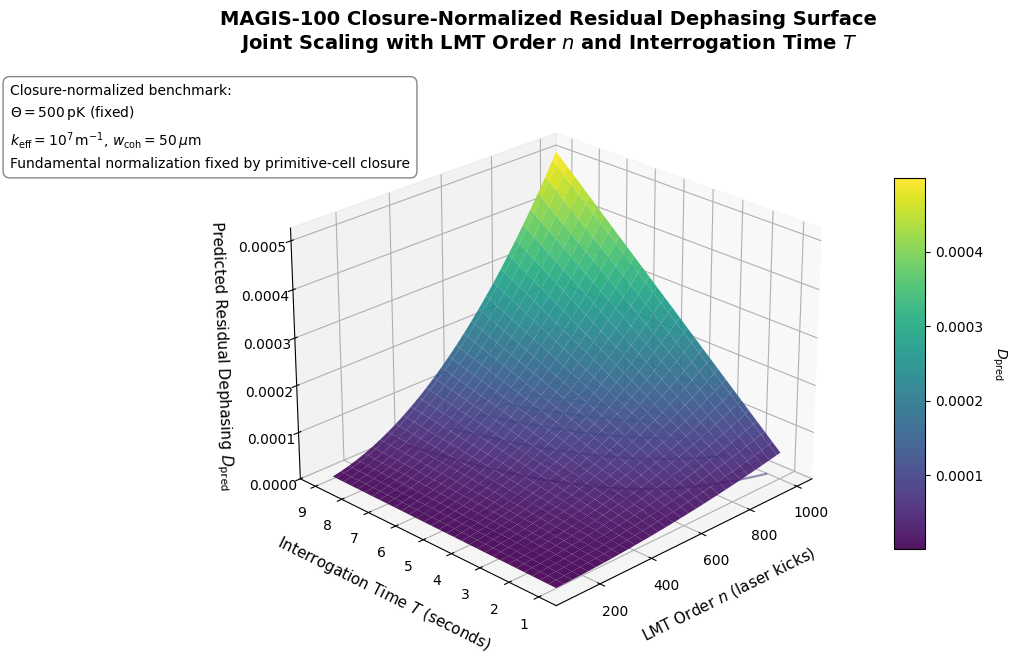

In [37]:
import numpy as np
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ------------------------------------------------------------
# MAGIS-100 closure-normalized 3D forecast surface
# ------------------------------------------------------------

# -----------------------------
# Fundamental constants (SI)
# -----------------------------
C = 299_792_458.0
L_PLANCK = 1.616_255e-35
HBAR = 1.054_571_817e-34
K_B = 1.380_649e-23
AMU = 1.660_539_066_60e-27

# -----------------------------
# Atomic species (Sr-87)
# -----------------------------
M_ATOM = 87.0 * AMU

# -----------------------------
# Closure / geometry inputs
# -----------------------------
CHI = 1.0
ETA = math.pi
I_STAR_OVER_A = 3.28
XI_TH = 1.0

# -----------------------------
# Updated benchmark inputs
# -----------------------------
THETA_FIXED = 500e-12     # 500 pK (can change to 600e-12 if desired)
K_EFF = 1.0e7             # 1/m
W_COH = 50e-6             # 50 microns

# -----------------------------
# Thermal prefactor
# -----------------------------
def thermal_prefactor(
    chi=CHI,
    eta=ETA,
    i_star_over_a=I_STAR_OVER_A,
    xi_th=XI_TH,
    k_eff=K_EFF,
    w_coh=W_COH,
    m_atom=M_ATOM,
):
    geom_part = (chi / (2.0 * eta * xi_th**2)) * i_star_over_a
    vacuum_part = C * L_PLANCK
    lab_part = (k_eff**2) * (w_coh**2) * (m_atom * K_B / HBAR**2)
    return geom_part * vacuum_part * lab_part


def calc_dpred(n: np.ndarray, T: np.ndarray, Theta: float = THETA_FIXED) -> np.ndarray:
    A = thermal_prefactor()
    return A * T * (n**2) * Theta


# -----------------------------
# Generate grid data
# -----------------------------
n_vals = np.linspace(100, 1000, 60)
T_vals = np.linspace(1, 9, 60)

N, T = np.meshgrid(n_vals, T_vals)
D_PRED = calc_dpred(N, T, THETA_FIXED)

# -----------------------------
# Plot
# -----------------------------
plt.rcParams["font.family"] = "sans-serif"
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Surface
surf = ax.plot_surface(
    N, T, D_PRED,
    cmap="viridis",
    edgecolor="none",
    alpha=0.92
)

# Bottom contours
zmin = 0.0
ax.contour(
    N, T, D_PRED,
    zdir="z",
    offset=zmin,
    cmap="viridis",
    alpha=0.55
)

# -----------------------------
# Labels & formatting
# -----------------------------
ax.set_title(
    "MAGIS-100 Closure-Normalized Residual Dephasing Surface\n"
    r"Joint Scaling with LMT Order $n$ and Interrogation Time $T$",
    fontsize=14,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("LMT Order $n$ (laser kicks)", fontsize=11, labelpad=10)
ax.set_ylabel("Interrogation Time $T$ (seconds)", fontsize=11, labelpad=10)
ax.set_zlabel(r"Predicted Residual Dephasing $D_{\mathrm{pred}}$", fontsize=11, labelpad=10)

ax.set_zlim(zmin, D_PRED.max() * 1.03)

# Colorbar
cbar = fig.colorbar(surf, ax=ax, shrink=0.58, aspect=12, pad=0.08)
cbar.set_label(r"$D_{\mathrm{pred}}$", rotation=270, labelpad=18)

# View
ax.view_init(elev=25, azim=-135)

# -----------------------------
# Annotation box (Locked to the Figure window, not the plot)
# -----------------------------
fig.text(
    0.04, 0.80,
    r"Closure-normalized benchmark:" "\n"
    r"$\Theta = 500\,\mathrm{pK}$ (fixed)" "\n"
    r"$k_{\rm eff}=10^7\,\mathrm{m}^{-1}$, $w_{\rm coh}=50\,\mu\mathrm{m}$" "\n"
    r"Fundamental normalization fixed by primitive-cell closure",
    fontsize=10,
    linespacing=1.5,
    va="top",
    bbox=dict(facecolor="white", alpha=0.95, edgecolor="gray", boxstyle="round,pad=0.5")
)

# -----------------------------
# Explicit Spacing Adjustments
# -----------------------------
plt.subplots_adjust(left=0.25, right=0.87, bottom=0.05, top=0.85)

# plt.savefig("magis_closure_surface_3d_v2.png", dpi=300, bbox_inches="tight")

plt.show()

## Quick Single-Point Calculator

For users who want a fast numerical check of the closure-normalized NDK residual dephasing for a specific operating point, the cell below serves as a simple single-point calculator. Enter a chosen interrogation time $T$, LMT order $n$, source temperature $\Theta$, and transverse coherence-support width $w_{\mathrm{coh}}$ to evaluate the predicted residual dephasing exponent $D_{\mathrm{pred}}$ and the corresponding fractional visibility loss.

Unlike the sweep figures above, this calculator does not map out a family of curves or a transfer-sensitivity band. Its purpose is to provide a direct magnitude estimate for one selected experimental configuration using the same thermal forecast law and closure inputs used throughout the notebook.

In [41]:
import math

# -----------------------------
# Fundamental constants (SI)
# -----------------------------
C = 299_792_458.0
L_PLANCK = 1.616_255e-35
HBAR = 1.054_571_817e-34
K_B = 1.380_649e-23
AMU = 1.660_539_066_60e-27

# -----------------------------
# Atomic species
# -----------------------------
M_ATOM = 87.0 * AMU   # Sr-87

# -----------------------------
# Closure / geometry inputs
# -----------------------------
CHI = 1.0
ETA = math.pi
I_STAR_OVER_A = 3.28
XI_TH = 1.0

def predict_dephasing(n, T, Theta, k_eff=1.0e7, w_coh=30e-6):
    geom_part = (CHI / (2.0 * ETA * XI_TH**2)) * I_STAR_OVER_A
    vacuum_part = C * L_PLANCK
    lab_part = (k_eff**2) * (w_coh**2) * (M_ATOM * K_B / HBAR**2)
    return geom_part * vacuum_part * lab_part * T * (n**2) * Theta

# -----------------------------------
# Choose your point here
# -----------------------------------
n = 1000
T = 9.0
Theta = 500e-12
k_eff = 1.0e7
w_coh = 50e-6

D = predict_dephasing(n=n, T=T, Theta=Theta, k_eff=k_eff, w_coh=w_coh)

print(f"Predicted dephasing variance: D_pred = {D:.4e}")
print(f"Corresponding contrast loss:  {1 - math.exp(-D):.4%}")

Predicted dephasing variance: D_pred = 5.1036e-04
Corresponding contrast loss:  0.0510%
